# Load groundwork 

In [1]:
# scvi.settings.seed = 0
# scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
# vae = scvi.model.SCVI(h5_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
# vae.train()
# h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()

# sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
# sc.tl.umap(h5_rna, min_dist=0.3)

# print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
# vae_model_folder=os.path.join(entropy_dir, "_RNA_scvi_model")
# vae.save(vae_model_folder)



## Marker genes

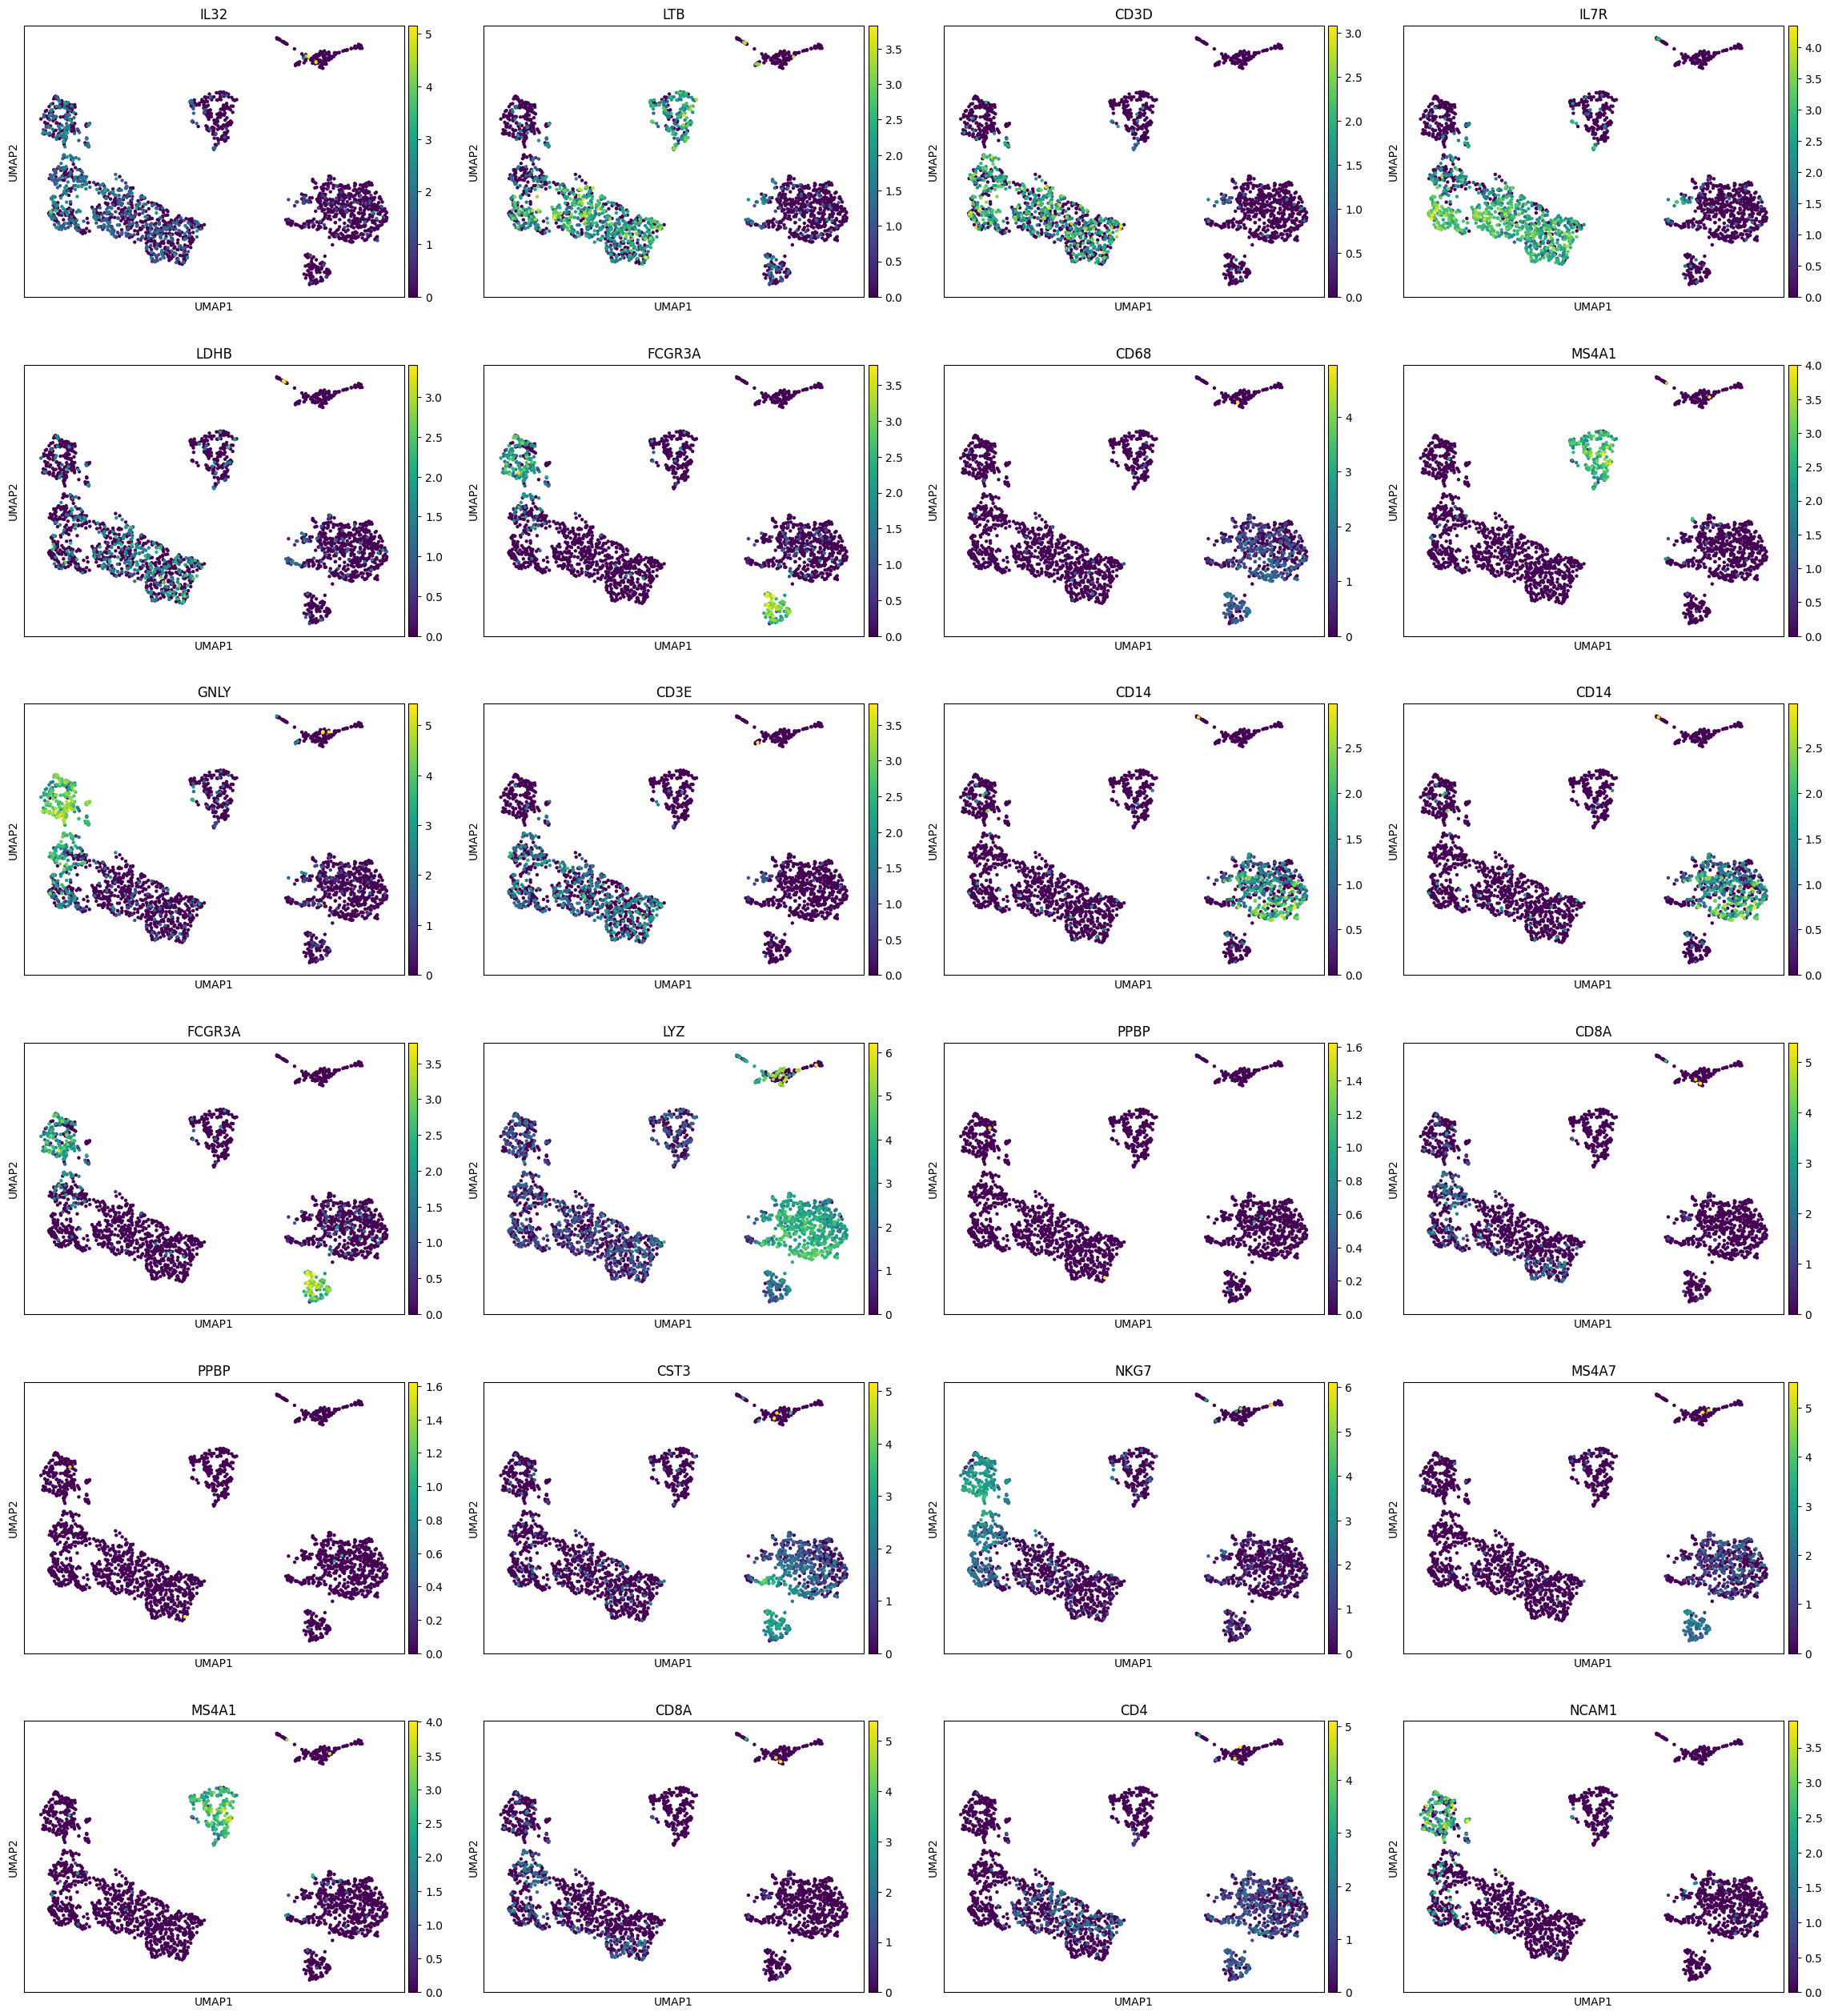

In [ ]:

canonical_markers_avail = [g for g in canonical_markers if g in h5_rna.var['gene_name'].values ]


# with plt.rc_context({'figure.figsize': (5, 5)}):
sc.pl.umap(h5_rna, color=canonical_markers_avail, wspace=0.1, ncols=4, size=40, gene_symbols='gene_name', layer='log1p_counts')

In [ ]:
sc.pl.umap(h5_rna, color=['SELL', 'IL7R', 'ITGAM'], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD127 protein : gene IL7R (T cells subtype)
# CD62L protein : gene SELL (T cells subtype)
# CD11B protein: ITGAM gene: T cells do not express ITGAM (myloid)

In [ ]:
sc.pl.umap(h5_rna, color=['CD3D', 'IL7R', 'CD8A', 'CD8B',  'NKG7', 'GNLY', 'FGFBP2', 'FCGR3A', 'FCER1G'], size=40 , gene_symbols='gene_name', layer='log1p_counts')

In [ ]:
sc.pl.umap(h5_rna, color=[ 'ITGAX',   'CD14','FCGR3A' ], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD11c protein: gene ITGAX -- DC 
# CD16 protein: gene FCGR3A -- NC monocytes

#### gamma-delta T cells 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'TRDC',   'TRGC1','TRDV2', 'TRGV9'], size=40 , ncols=2, gene_symbols='gene_name', layer='log1p_counts') #

### pDCs and C14+ monocytes

In [ ]:
sc.pl.umap(h5_rna, color=[ 'CD14', 'IRF7', 'TLR9', 'TCF4', 'CLEC4C' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

####  MAIT/NK-T cells 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'KLRG1',   'NCR3','KLRB1'], size=40 ,gene_symbols='gene_name', layer='log1p_counts') #

#### 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'NCAM1',   'TBX21','IFNG', 'NKG7', 'XCL2', 'NCR1' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

#### Mono 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'CD14',   'HLA-DRA', 'TNF', 'IL1B' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

In [ ]:
# cell-type idendification by Juliana

cluster_average_df = pd.DataFrame(index=h5_rna.var['gene_name'])

for c in h5_rna.obs['leiden_RNA_scVI'].unique():
    a = h5_rna[h5_rna.obs['leiden_RNA_scVI'] == c, :].layers['log1p_counts'].mean(axis=0)
    cluster_average_df[c] = np.asarray(a).flatten()
    
cluster_average_df.to_csv('HiJuliana_check_pbmc_rna_cluster_average_normalized_expression.csv')

cluster_average_df.head()

## Cell-type annotation from Julianaa

## Save average gene expression per cluster for Juliana to annotate cell-types

In [52]:
RNA_cell_clusters = h5_rna.obs['leiden_RNA_scVI'].unique()

cluster_gene_df = pd.DataFrame(index=h5_rna.var['gene_name'])

for c in RNA_cell_clusters:
    a = h5_rna[h5_rna.obs['leiden_RNA_scVI'] == c, :].layers['counts'].mean(axis=0)
    cluster_gene_df[c] = np.asarray(a).flatten()
    
save_file = os.path.join(entropy_dir, 'HiJuliana_check_pbmc_rna_cluster_average_raw_counts_UpdatedEntropyNormalization.csv')
cluster_gene_df.to_csv(save_file)

### Provicve clsuter to cell-type map

In [16]:
# Juliana's cell type annotation
# Juliana's cell type annotation
RNAcluster_celltype_map = {
'0': 'CD14+ Mo',
'1': 'CD4+CD8+ naive T cells',
'2': 'Tregs',
'3': 'B cells',
'4': 'ILC/NK cells',
'5': 'MAIT/NK T cells',
'6': 'gammaSignma T cells',
'7': 'Unknown',
'8': 'CD16+Mo',
'9': 'pDCs',
'10': 'Plasma cells (noisy)'
}
h5_rna.obs['celltype'] = h5_rna.obs['leiden_RNA_scVI'].map(RNAcluster_celltype_map)

## do NOT !!! delete 
## do NOT !!! delete 
## do NOT !!! delete 


# ## Save each cell-type's barcode 
# rna_cell_type_subdir = os.path.join(entropy_dir,  '_rna_cell_types')
# os.makedirs(rna_cell_type_subdir, exist_ok=True)

# #
# for cluster in h5_rna.obs['leiden_RNA_scVI'].unique():
#     write_file = 'RNAcluster_' + str(cluster) + '_df.csv' 
#     write_file_path = os.path.join(rna_cell_type_subdir, write_file)
#     h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == cluster, :].to_csv(write_file_path, index=False)
    
# # write cell-type mapping file
# celltype_map_file = os.path.join(rna_cell_type_subdir, 'RNAcluster_celltype_map.tsv')
# with open(celltype_map_file, 'w') as f:
#     for k, v in RNAcluster_celltype_map.items():
#         f.write(f"{k}\t{v}\n")

### plot to see cell-type fraction of reads in peaks (FRIP) for standard peak set and entropy peak set

In [17]:
if 'standard_peak_FRIP' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['standard_peak_FRIP'], inplace=True)
if 'entropy_peak_FRIP' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['entropy_peak_FRIP'], inplace=True)
    
h5_rna.obs = h5_rna.obs.merge(standard_peak_frip[['frag_overlap_peaks%']].rename(columns={'frag_overlap_peaks%': 'standard_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')

h5_rna.obs = h5_rna.obs.merge(entropy_peak_frip[['frag_overlap_entropy_peaks%']].rename(columns={'frag_overlap_entropy_peaks%': 'entropy_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')

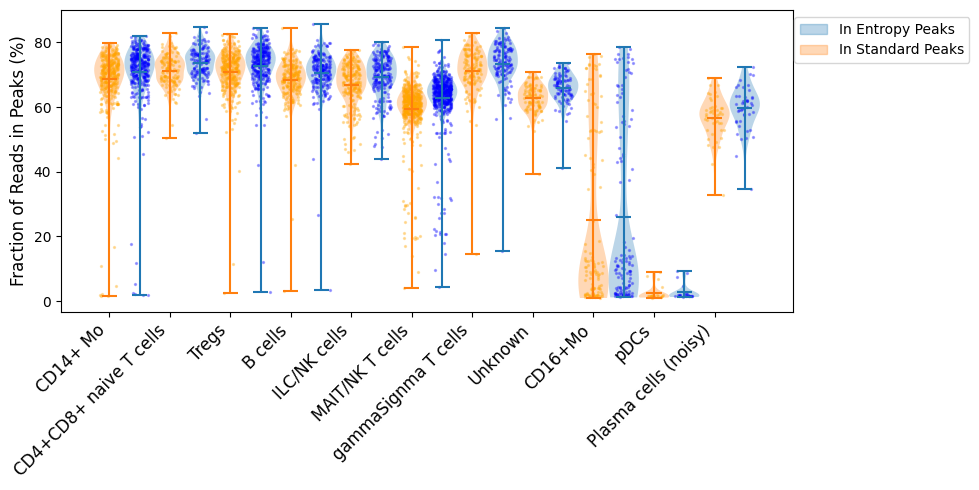

In [18]:
# color_maps = {'0': 'blue', '1': 'orange', '2': 'green', '3': 'red', '4': 'purple',
#               '5': 'brown', '6': 'pink', '7': 'gray', '8': 'olive', '9': 'cyan', '10': 'magenta'}
x_positions = range(11)
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(10, 5))

# Violin plots
standard_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'standard_peak_FRIP'] for c in h5_rna.obs['leiden_RNA_scVI'].unique()]
entropy_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'entropy_peak_FRIP'] for c in h5_rna.obs['leiden_RNA_scVI'].unique()]
add_label(ax.violinplot( entropy_peak_data, 
              positions=[x + widths for x in x_positions], widths=widths, vert=True, 
              showmeans=True,), 'In Entropy Peaks',)

add_label(ax.violinplot( standard_peak_data, 
              positions=x_positions, widths=widths, vert=True, 
              showmeans=True), 'In Standard Peaks',)


# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='blue'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size

for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i], color='orange')
for i, group_data in enumerate(entropy_peak_data):
    add_jittered_points(ax, group_data, [x + widths for x in x_positions][i], color='blue')



ax.set_xticks(x_positions)
ax.set_xticklabels([RNAcluster_celltype_map[str(c)] for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(1.25, 1), ncol=1)

plt.tight_layout()


In [19]:
h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['Entropy', 'Entropy_open_region']], left_on='atac_bc', right_index=True, how='left')
h5_rna.obs['Entropy_log'] = np.log10(h5_rna.obs['Entropy'])

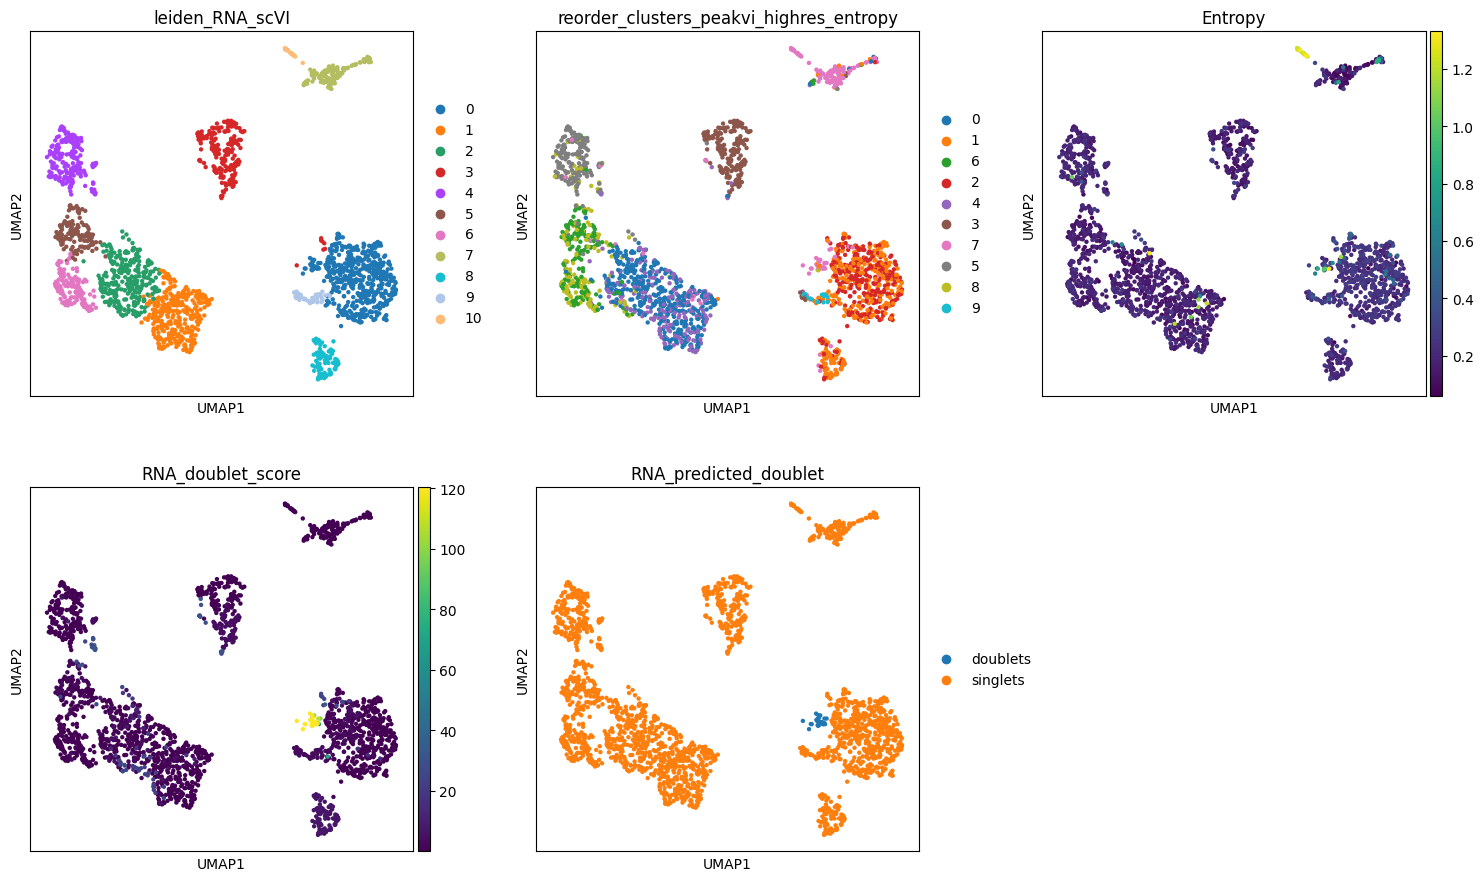

In [65]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(h5_rna, color=["leiden_RNA_scVI", "reorder_clusters_peakvi_highres_entropy", "Entropy", "RNA_doublet_score", "RNA_predicted_doublet"], size=40, ncols=3, wspace=0.2)
    

Text(0, 0.5, 'Entropy Score')

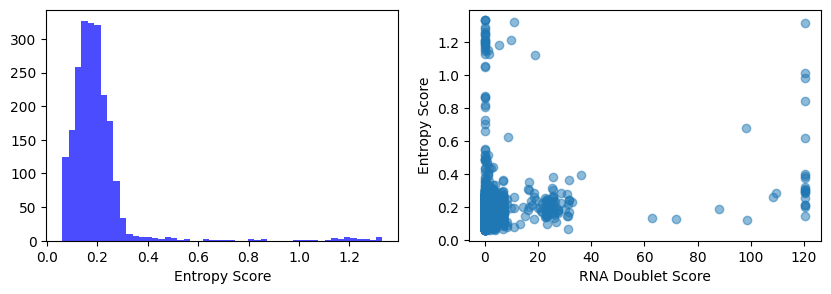

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
_ = ax[0].hist(h5_rna.obs['Entropy'], bins=50, color='blue', alpha=0.7)
ax[0].set_xlabel('Entropy Score')

ax[1].scatter(h5_rna.obs['RNA_doublet_score'], h5_rna.obs['Entropy'],  alpha=0.5)
ax[1].set_xlabel('RNA Doublet Score')
ax[1].set_ylabel('Entropy Score')

Text(0.5, 0, 'Entropy value (log)')

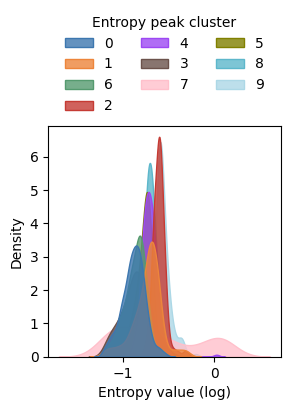

In [66]:
color_order = {'0': '#3d77af', '1': '#ed853b', '2': '#559a6f', '3': '#c53b34', '4': '#9d48f3',
             '5': '#6b524b', '6': 'pink', '7': 'olive', '8': '#5db7cb', '9': 'lightblue', 
                '10': '#f6a04d', '11': '#8fd18b', '12': 'lightcoral'}#, '13': 'lime'}
entropy_peak_cluster_order = h5_rna.obs['reorder_clusters_peakvi_highres_entropy'].cat.categories.tolist()
color_map = {k: color_order[str(i)] for i, k in enumerate(entropy_peak_cluster_order)}

fig, ax = plt.subplots(figsize=(3, 3))
kde = sns.kdeplot(data=h5_rna.obs, x='Entropy_log', hue='reorder_clusters_peakvi_highres_entropy', 
                  palette=color_map,
                  fill=True, 
                  ax=ax, alpha=0.8, common_norm=False)
sns.move_legend(
    kde, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title='Entropy peak cluster', frameon=False
)

ax.set_xlabel('Entropy value (log)')


In [67]:
h5_rna.obs['reorder_clusters_peakvi_highres_entropy'].cat.categories

Index(['0', '1', '6', '2', '4', '3', '7', '5', '8', '9'], dtype='object')

### closer look at Entropy cluster 7

In [68]:
entropy_c12_h5 = h5_rna[h5_rna.obs['clusters_peakvi_highres_entropy'] == '7', :].copy()

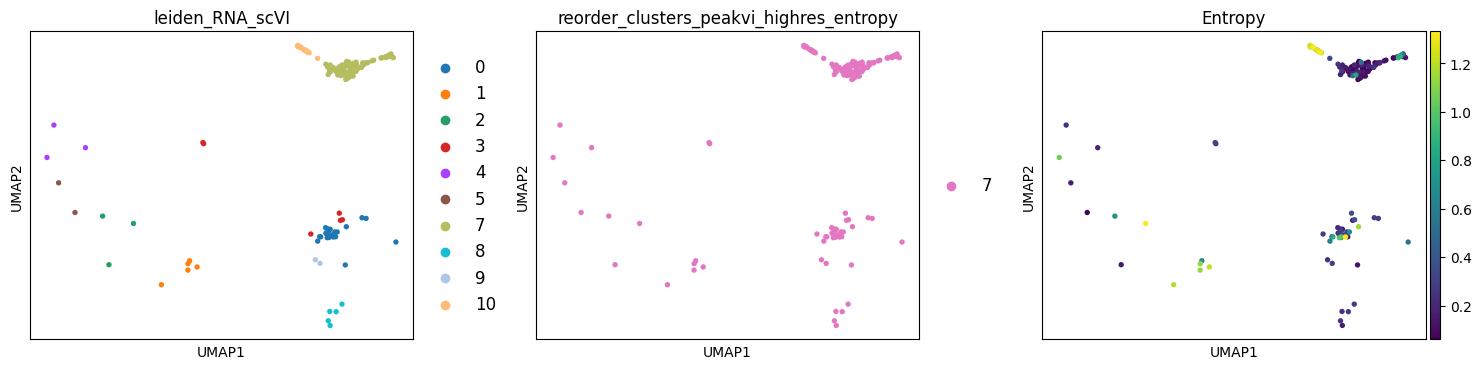

In [69]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(entropy_c12_h5, color=['leiden_RNA_scVI', 'reorder_clusters_peakvi_highres_entropy', 'Entropy'], wspace=0.2, ncols=3, size=60, legend_fontsize=12, show=False)
    

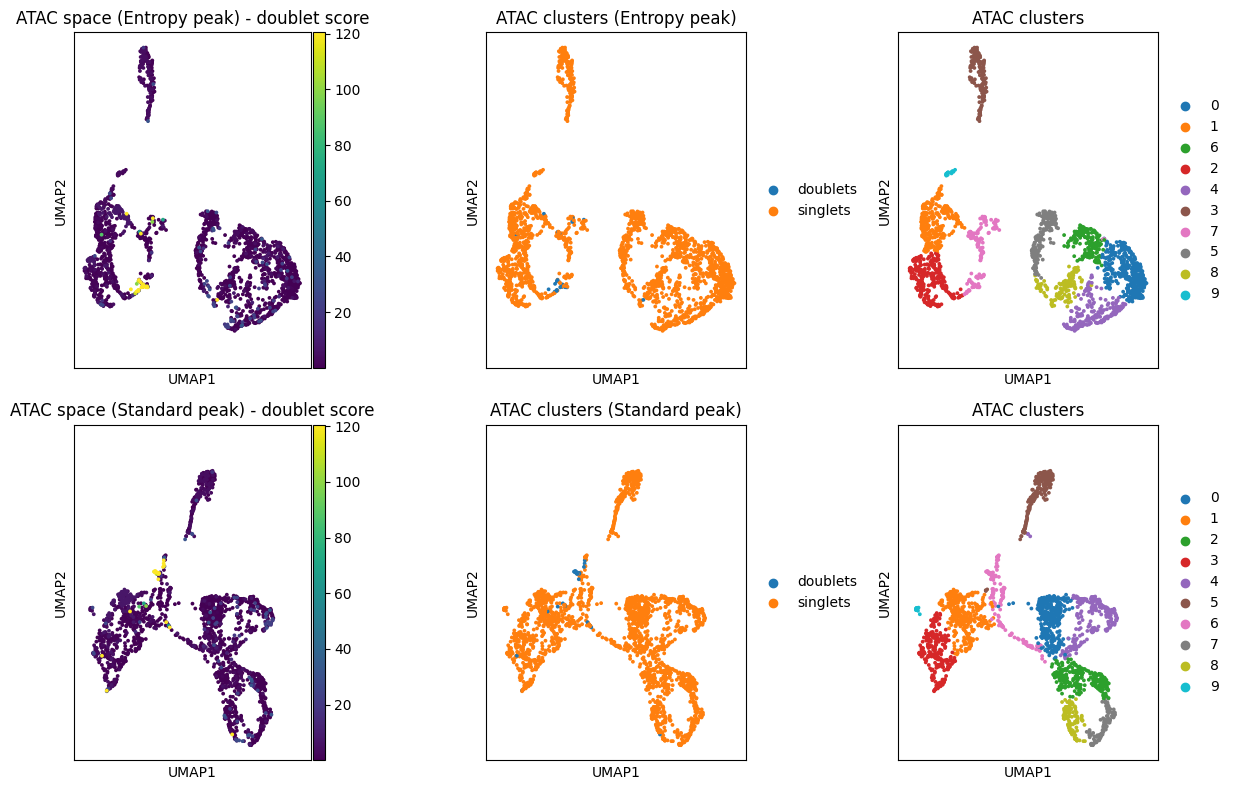

In [76]:
if 'RNA_doublet_score' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('RNA_doublet_score', axis=1, inplace=True)
if 'RNA_predicted_doublet' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('RNA_predicted_doublet', axis=1, inplace=True)
    
if 'RNA_doublet_score' in peak.obs.columns:
    peak.obs.drop('RNA_doublet_score', axis=1, inplace=True)
if 'RNA_predicted_doublet' in peak.obs.columns:
    peak.obs.drop('RNA_predicted_doublet', axis=1, inplace=True)
    
entropy_peak.obs = entropy_peak.obs.merge(h5_rna.obs[['RNA_doublet_score', 'RNA_predicted_doublet']], left_on='rna_barcodes', right_index=True, how='left')
peak.obs = peak.obs.merge(h5_rna.obs[['RNA_doublet_score', 'RNA_predicted_doublet']], left_on='rna_barcodes', right_index=True, how='left')




fig, ax = plt.subplots(2, 3, figsize=(12,8), sharex=True, sharey=True)
ax = ax.flatten()
sc.pl.umap(entropy_peak, color=['RNA_doublet_score'], title='ATAC space (Entropy peak) - doublet score', size=30, ax=ax[0], show=False)
sc.pl.umap(entropy_peak, color=['RNA_predicted_doublet'], title='ATAC clusters (Entropy peak)', size=30, ax=ax[1], show=False)
sc.pl.umap(entropy_peak, color=['reorder_clusters_peakvi_highres_entropy'], title='ATAC clusters', size=30, ax=ax[2], show=False)


sc.pl.umap(peak, color=['RNA_doublet_score'], title='ATAC space (Standard peak) - doublet score', size=30, ax=ax[3], show=False)
sc.pl.umap(peak, color=['RNA_predicted_doublet'], title='ATAC clusters (Standard peak)', size=30, ax=ax[4], show=False)
sc.pl.umap(peak, color=['clusters_peakvi_highres_standard'], title='ATAC clusters', size=30, ax=ax[5], show=False)

fig.tight_layout()

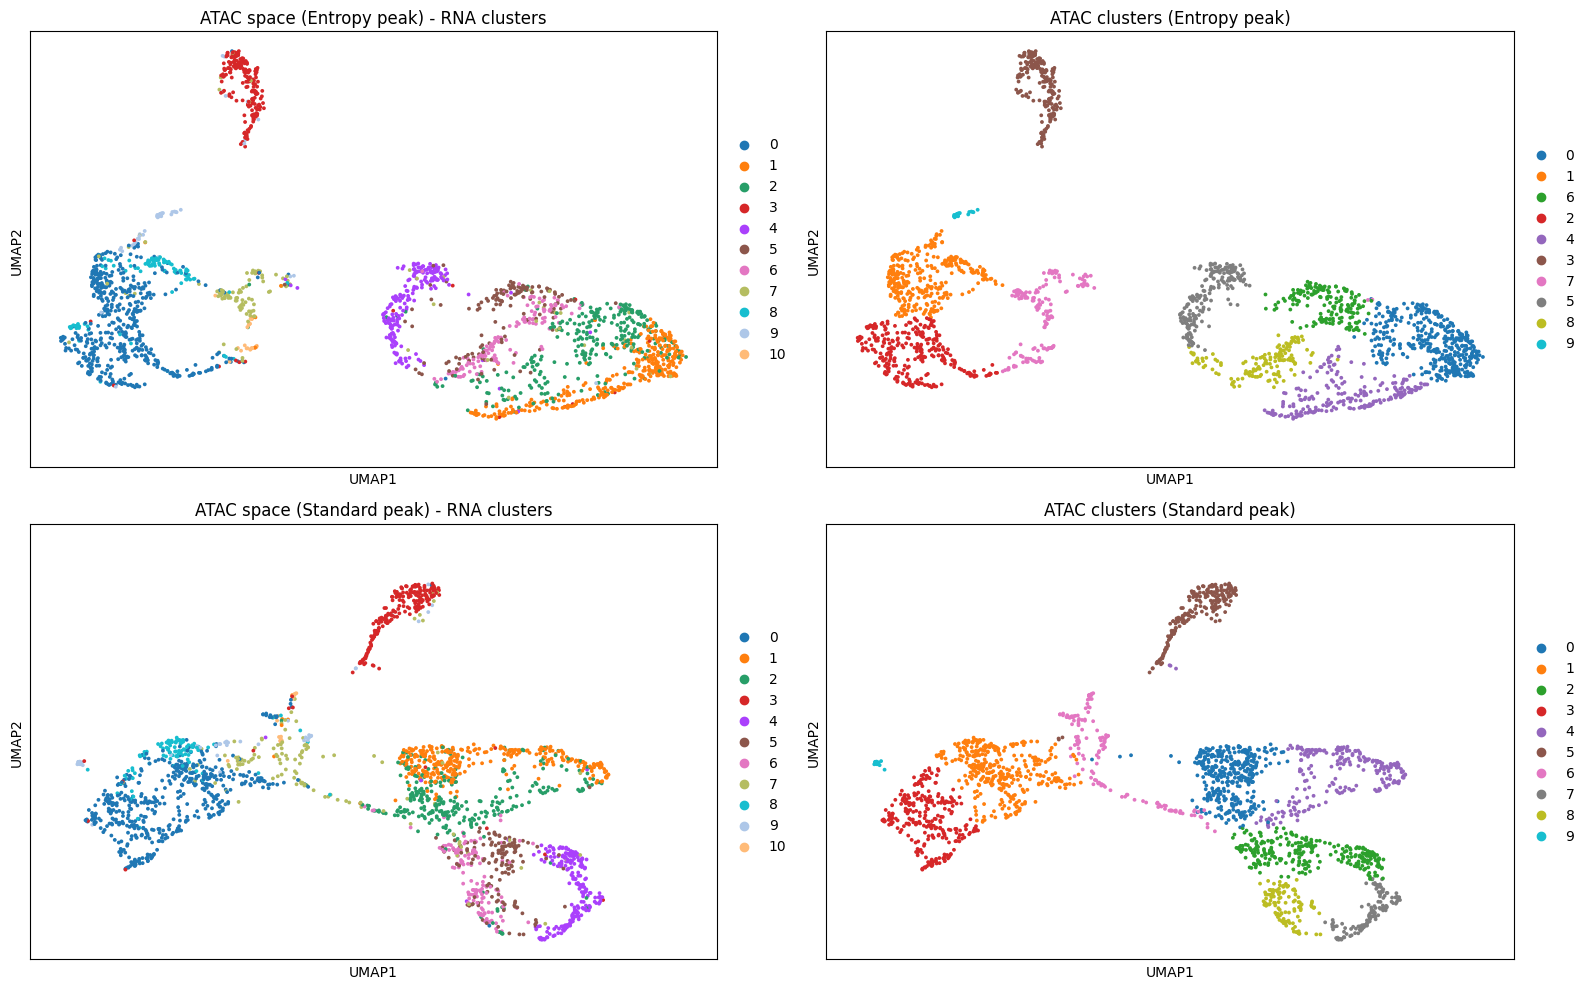

In [70]:
if 'leiden_RNA_scVI' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
if 'leiden_RNA_scVI' in peak.obs.columns:
    peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
    
entropy_peak.obs = entropy_peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')
peak.obs = peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')



fig, ax = plt.subplots(2, 2, figsize=(16,10), sharex=True, sharey=True)
ax = ax.flatten()
sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI'], title='ATAC space (Entropy peak) - RNA clusters', size=30, ax=ax[0], show=False)
sc.pl.umap(entropy_peak, color=['reorder_clusters_peakvi_highres_entropy'], title='ATAC clusters (Entropy peak)', size=30, ax=ax[1], show=False)


sc.pl.umap(peak, color=['leiden_RNA_scVI'], title='ATAC space (Standard peak) - RNA clusters', size=30, ax=ax[2], show=False)
sc.pl.umap(peak, color=['clusters_peakvi_highres_standard'], title='ATAC clusters (Standard peak)', size=30, ax=ax[3], show=False)


fig.tight_layout()

## DARs analysis to see top peaks 

### Get Differentially accessible regions on Standard peak set, and Entropy peak set respectively

In [99]:
# NK-cells  
## NCR1  
# name: peak_19704
# location: chr19:54905933-54906212
# score: 835.0

# B cells
## MS4A1 
# name: peak_6326
# location: chr11:60455546-60455895
# score: 1000.0

# Activated CD8+ T cells
## IFNG
# name: peak_8656
# location: chr12:68159654-68160000
# score: 1000.0

# # T-cells 
## CD3D
# name: peak_7310
# location: chr11:118338531-118339381
# score: 1000.0
# name: peak_7311
# location: chr11:118344195-118344434
# score: 1000.0


# CD4+ T cells
## CD4
# name: peak_7743
# location: chr12:6789380-6789719
# score: 1000.0
# name: peak_7744
# location: chr12:6792633-6793231
# score: 1000.0

# T-reg CD4+ T cells
## FOXP3
# name: peak_37110
# location: chrX:49235357-49235915
# score: 940.0

# CD8+ T cells
## CD8A
# name: peak_20882
# location: chr2:86785468-86785833
# score: 1000.0
# name: peak_20883
# location: chr2:86786051-86786600
# score: 1000.0
# name: peak_20884
# location: chr2:86790583-86791587
# score: 644.0

# Mono
## TNF
# name: peak_21239
# location: chr2:112836678-112837043
# score: 1000.0
# Intermediate Mono
# name: peak_30585
# location: chr6:31575336-31575912
# score: 1000.0
## HLA-DRA
# name: peak_30637
# location: chr6:32439390-32440066
# score: 1000.0

# Classical Monocytes
## CD14
# name: peak_29379
# location: chr5:140631052-140631380
# score: 1000.0
# name: peak_29380
# location: chr5:140631995-140633887
# score: 748.0

# Dendritic Cells
## DNAI2
# name: peak_16318
# location: chr17:74280030-74280540
# score: 1000.0
# name: peak_16319
# location: chr17:74282729-74283423
# score: 905.0
# name: peak_16320
# location: chr17:74301243-74301427
# score: 1000.0

# with plt.rc_context({'figure.figsize': (5, 5)}):
#     sc.pl.umap(entropy_peak_plot, color=['clusters_peakvi_highres_entropy', 'leiden_RNA_scVI', \
#         'peak_19704', 'peak_6326', 'peak_8656', \
#             'peak_7310','peak_7311', 'peak_7743', 'peak_7744', \
#                 'peak_37110' , \
#                     'peak_20882', 'peak_20883', 'peak_20884', \
#                         'peak_21239' , \
#                             'peak_30585', 'peak_30637', \
#                                 'peak_29379', 'peak_29380', \
#                                     'peak_16318', 'peak_16319', 'peak_16320'], \
#         size=40 , ncols=3, layer=None) 